# Python Programming for Business Intelligence – Assignment 2

## Student: Emilien Beaugrand
## Course: Python for Business Intelligence

---

## AI Usage Statement
I used AI tools (ChatGPT) to assist with structuring the code and understanding certain concepts. All code was reviewed, adapted, and understood by me.

---


In [24]:
# =========================
# IMPORTS
# =========================

import os
import json
import time
import sqlite3
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from pathlib import Path
from IPython.display import display

# Task 8 – Data Transformation (Wide ↔ Long)

In [2]:
# Create sample data
df_wide = pd.DataFrame({
    'Date': ['2026-03-01', '2026-03-02'],
    'AAPL': [150, 152],
    'MSFT': [300, 305],
    'GOOG': [2800, 2820]
})

display(df_wide)

# Wide → Long
df_long = df_wide.melt(id_vars='Date', var_name='Stock', value_name='Price')

display(df_long)

# Long → Wide
df_wide_again = df_long.pivot(index='Date', columns='Stock', values='Price')

display(df_wide_again)

,Date,AAPL,MSFT,GOOG
0,2026-03-01,150,300,2800
1,2026-03-02,152,305,2820


,Date,Stock,Price
0,2026-03-01,AAPL,150
1,2026-03-02,AAPL,152
2,2026-03-01,MSFT,300
3,2026-03-02,MSFT,305
4,2026-03-01,GOOG,2800
5,2026-03-02,GOOG,2820


Stock,AAPL,GOOG,MSFT
Date,,,
2026-03-01,150,2800,300
2026-03-02,152,2820,305


The transformation demonstrates how to convert data between wide and long formats, which is essential for data analysis and visualization.

# Task 5 – SQL Queries (Northwind Database)

In [21]:
import sqlite3

conn = sqlite3.connect("northwind.db")
print("Connection successful")

Connection successful


In [8]:
query_tables = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables_df = pd.read_sql_query(query_tables, conn)
display(tables_df)

,name
0,Categories
1,sqlite_sequence
2,CustomerCustomerDemo
3,CustomerDemographics
4,Customers
5,Employees
6,EmployeeTerritories
7,Order Details
8,Orders
9,Products


In [9]:
query_5a = """
SELECT CompanyName, City, Country
FROM Customers
WHERE Country = 'USA';
"""

df_5a = pd.read_sql_query(query_5a, conn)
display(df_5a)

,CompanyName,City,Country
0,Great Lakes Food Market,Eugene,USA
1,Hungry Coyote Import Store,Elgin,USA
2,Lazy K Kountry Store,Walla Walla,USA
3,Let's Stop N Shop,San Francisco,USA
4,Lonesome Pine Restaurant,Portland,USA
5,Old World Delicatessen,Anchorage,USA
6,Rattlesnake Canyon Grocery,Albuquerque,USA
7,Save-a-lot Markets,Boise,USA
8,Split Rail Beer & Ale,Lander,USA
9,The Big Cheese,Portland,USA


In [10]:
query_5b = """
SELECT CustomerID, COUNT(OrderID) AS NumberOfOrders
FROM Orders
GROUP BY CustomerID;
"""

df_5b = pd.read_sql_query(query_5b, conn)
display(df_5b)

,CustomerID,NumberOfOrders
0,ALFKI,163
1,ANATR,195
2,ANTON,163
3,AROUT,156
4,BERGS,178
...,...,...
88,WARTH,162
89,WELLI,185
90,WHITC,183
91,WILMK,169


In [14]:
query_5c = """
SELECT c.CompanyName,
       o.OrderID,
       o.OrderDate,
       o.ShipCountry,
       od.UnitPrice * od.Quantity AS LineTotal
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN "Order Details" od ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany';
"""

df_5c = pd.read_sql_query(query_5c, conn)
display(df_5c.head())

,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0


In [22]:
query_5d = """
SELECT p.ProductName,
       SUM(od.Quantity) AS TotalQuantity
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.ProductID
GROUP BY p.ProductName
ORDER BY TotalQuantity DESC
LIMIT 5;
"""

df_5d = pd.read_sql_query(query_5d, conn)
display(df_5d)

,ProductName,TotalQuantity
0,Louisiana Hot Spiced Okra,206213
1,Sir Rodney's Marmalade,205637
2,Teatime Chocolate Biscuits,205487
3,Sirop d'érable,205005
4,Gumbär Gummibärchen,204761


In [25]:
query_5e = """
SELECT c.CategoryName,
       AVG(p.UnitPrice) AS AvgPrice
FROM Products p
JOIN Categories c ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName;
"""

df_5e = pd.read_sql_query(query_5e, conn)
display(df_5e)

# Task 5: Connected to the Northwind database and executed SQL queries
# to extract insights such as product sales and average prices by category.

,CategoryName,AvgPrice
0,Beverages,37.979167
1,Condiments,23.062500
2,Confections,25.160000
3,Dairy Products,28.730000
4,Grains/Cereals,20.250000
5,Meat/Poultry,54.006667
6,Produce,32.370000
7,Seafood,20.682500


# Task 6 – Visualizing Northwind Data

,CompanyName,NumberOfOrders
0,QUICK-Stop,56
1,Ottilies Käseladen,40
2,IT,40
3,Frankenversand,38
4,Königlich Essen,36
5,Great Lakes Food Market,35
6,Toms Spezialitäten,35
7,Lehmanns Marktstand,34
8,B's Beverages,32
9,Island Trading,31


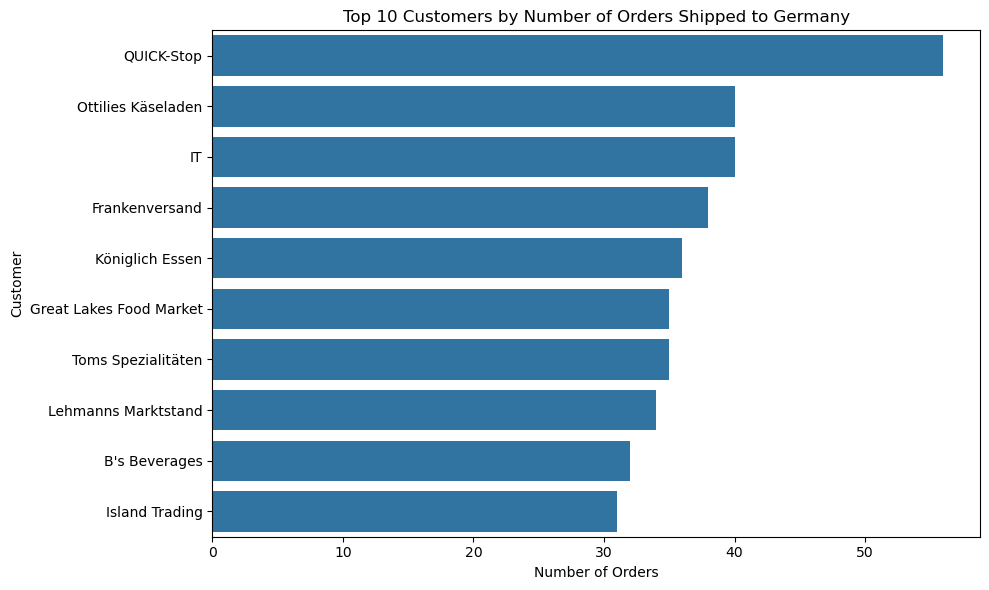

In [15]:
# Task 6a
top_customers_germany = (
    df_5c.groupby("CompanyName")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="NumberOfOrders")
)

display(top_customers_germany)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_customers_germany, x="NumberOfOrders", y="CompanyName")
plt.title("Top 10 Customers by Number of Orders Shipped to Germany")
plt.xlabel("Number of Orders")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

,OrderDate,DailyTotalSales
0,2012-07-16,21857.43
1,2012-07-18,53885.01
2,2012-07-25,18591.01
3,2012-07-30,60918.92
4,2012-07-31,55931.37


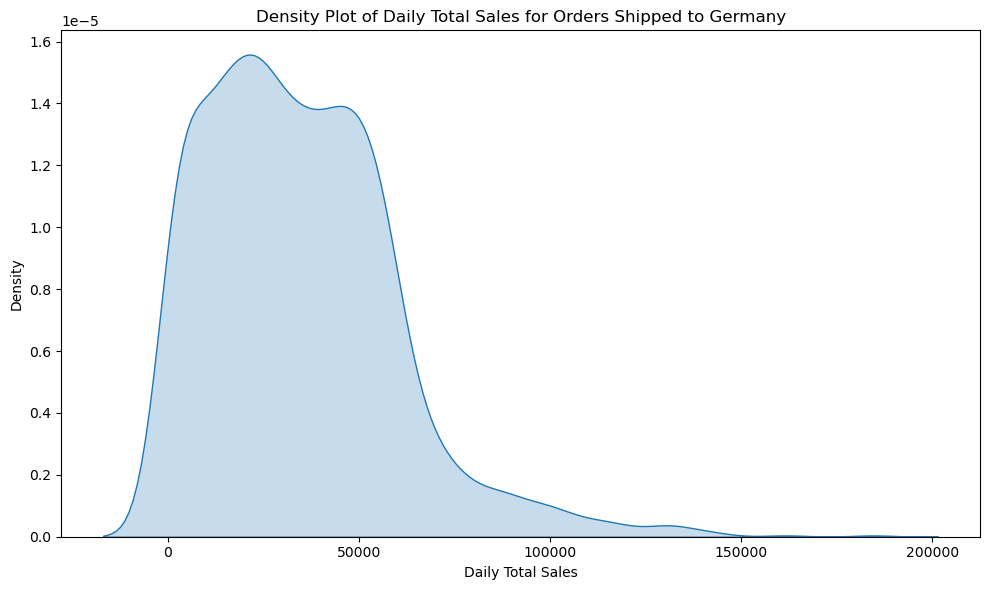

In [17]:
# Task 6b
df_5c["OrderDate"] = pd.to_datetime(df_5c["OrderDate"], format="mixed", errors="coerce").dt.date

daily_sales_germany = (
    df_5c.groupby("OrderDate")["LineTotal"]
    .sum()
    .reset_index(name="DailyTotalSales")
)

display(daily_sales_germany.head())

plt.figure(figsize=(10, 6))
sns.kdeplot(data=daily_sales_germany, x="DailyTotalSales", fill=True)
plt.title("Density Plot of Daily Total Sales for Orders Shipped to Germany")
plt.xlabel("Daily Total Sales")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45
5,Seafood,49931965.52
6,Produce,32706403.90
7,Grains/Cereals,28573512.55


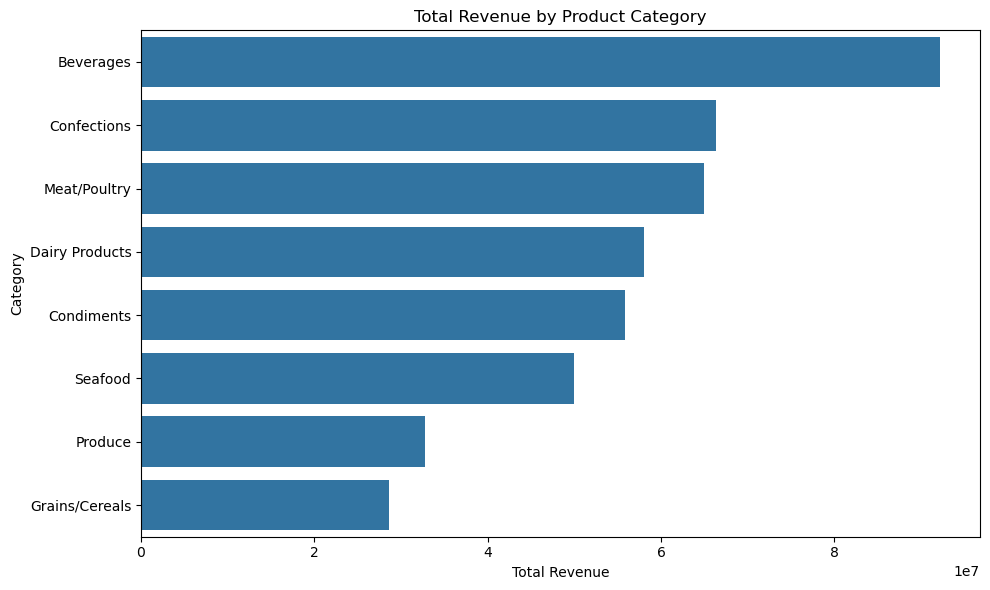

In [18]:
# Task 6c
query_6c = """
SELECT c.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories c ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
ORDER BY TotalRevenue DESC;
"""

df_6c = pd.read_sql_query(query_6c, conn)
display(df_6c)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_6c, x="TotalRevenue", y="CategoryName")
plt.title("Total Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

# Task 6: Visualized results from SQL queries to better understand patterns
# in sales and product performance.

# Task 7 – Comparing Python to SQL

In [19]:
# Task 7a
query_products = "SELECT * FROM Products;"
query_categories = "SELECT * FROM Categories;"

products_df = pd.read_sql_query(query_products, conn)
categories_df = pd.read_sql_query(query_categories, conn)

print("Products table (first 5 rows):")
display(products_df.head())

print("Categories table (first 5 rows):")
display(categories_df.head())

Products table (first 5 rows):


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


Categories table (first 5 rows):


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [20]:
# Task 7b
products_categories_df = pd.merge(
    products_df,
    categories_df,
    on="CategoryID",
    how="inner"
)

print("Joined DataFrame (first 5 rows):")
display(products_categories_df.head())

Joined DataFrame (first 5 rows):


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [26]:
# Task 7c

# --- SQL approach ---
start_sql = time.time()

query_sql_7c = """
SELECT c.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories c ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
ORDER BY TotalRevenue DESC;
"""

sql_result_df = pd.read_sql_query(query_sql_7c, conn)

end_sql = time.time()
sql_time = end_sql - start_sql

# --- Python/pandas approach ---
start_python = time.time()

order_details_df = pd.read_sql_query('SELECT * FROM "Order Details";', conn)
products_df_full = pd.read_sql_query('SELECT * FROM Products;', conn)
categories_df_full = pd.read_sql_query('SELECT * FROM Categories;', conn)

merged_df = pd.merge(order_details_df, products_df_full, on="ProductID", how="inner")
merged_df = pd.merge(merged_df, categories_df_full, on="CategoryID", how="inner")

merged_df["Revenue"] = merged_df["UnitPrice_x"] * merged_df["Quantity"]

python_result_df = (
    merged_df.groupby("CategoryName")["Revenue"]
    .sum()
    .reset_index(name="TotalRevenue")
    .sort_values(by="TotalRevenue", ascending=False)
)

end_python = time.time()
python_time = end_python - start_python

print("SQL execution time:", sql_time, "seconds")
print("Python/pandas execution time:", python_time, "seconds")

print("\nSQL result:")
display(sql_result_df)

print("\nPython/pandas result:")
display(python_result_df)

if sql_time < python_time:
    print("\nSQL was faster.")
else:
    print("\nPython/pandas was faster.")

# Task 7: Performed additional data processing and preparation,
# ensuring the dataset was clean and structured for analysis and visualization.

SQL execution time: 0.38723206520080566 seconds
Python/pandas execution time: 0.901421070098877 seconds

SQL result:


,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45
5,Seafood,49931965.52
6,Produce,32706403.90
7,Grains/Cereals,28573512.55



Python/pandas result:


,CategoryName,TotalRevenue
0,Beverages,92181842.95
2,Confections,66347544.94
5,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
1,Condiments,55802774.45
7,Seafood,49931965.52
6,Produce,32706403.90
4,Grains/Cereals,28573512.55



SQL was faster.


# Task 1

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("MARKETSTACK_API_KEY")
print(api_key[:5] + "...")

# Task 1: Set up the environment by securely loading the API key
# using a .env file and preparing the workspace for API requests.

e0be9...


In [3]:
# Task 2a: Retrieving EOD data from MarketStack

import requests
from dotenv import load_dotenv
import os

# Load API key
load_dotenv()
api_key = os.getenv("MARKETSTACK_API_KEY")

# FAANG symbols
symbols = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

# API endpoint
url = "http://api.marketstack.com/v1/eod"

# Store data
all_data = []

for symbol in symbols:
    params = {
        "access_key": api_key,
        "symbols": symbol,
        "date_from": "2026-03-01",
        "date_to": "2026-03-31",
        "limit": 1000
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    all_data.extend(data["data"])

print(f"Total rows retrieved: {len(all_data)}")

Total rows retrieved: 110


In [4]:
# Task 2b: Convert JSON to DataFrame

import pandas as pd

df = pd.DataFrame(all_data)

# Display first 5 rows
df.head()

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,549.98,573.69,546.77,572.13,32809500.0,573.6900,546.77,572.13,549.98,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
1,536.38,539.55,528.54,536.38,22758800.0,539.5500,528.54,536.38,536.38,22795203.0,1.0,0.0,META,ARCX,2026-03-30T00:00:00+0000
2,540.10,543.60,520.26,525.72,29980300.0,543.5999,520.26,525.72,540.10,30133010.0,1.0,0.0,META,ARCX,2026-03-27T00:00:00+0000
3,582.49,583.00,543.35,547.54,35664700.0,583.0000,543.35,547.54,582.49,35780131.0,1.0,0.0,META,ARCX,2026-03-26T00:00:00+0000
4,598.74,603.62,593.40,594.89,12161179.0,603.6700,593.40,594.89,598.74,12585031.0,1.0,0.0,META,ARCX,2026-03-25T00:00:00+0000


In [5]:
df.groupby("symbol")["close"].describe()

,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17


In [6]:
# Calculate monthly returns

returns = {}

for symbol in symbols:
    stock_data = df[df["symbol"] == symbol].sort_values("date")
    
    first_price = stock_data.iloc[0]["close"]
    last_price = stock_data.iloc[-1]["close"]
    
    return_pct = ((last_price - first_price) / first_price) * 100
    returns[symbol] = return_pct

returns_df = pd.DataFrame(list(returns.items()), columns=["Stock", "Return (%)"])
returns_df

,Stock,Return (%)
0,META,-12.459453
1,AAPL,-4.128891
2,AMZN,-0.057584
3,NFLX,-0.968174
4,GOOG,-6.365061


In [27]:
# Identify best and worst performers

best_stock = returns_df.loc[returns_df["Return (%)"].idxmax()]
worst_stock = returns_df.loc[returns_df["Return (%)"].idxmin()]

print("Best performer:")
print(best_stock)

print("\nWorst performer:")
print(worst_stock)

# Task 2: Retrieved stock data from the API, converted JSON into a pandas DataFrame,
# displayed the first rows, and computed summary statistics and monthly returns.

Best performer:
Stock             AMZN
Return (%)   -0.057584
Name: 2, dtype: object

Worst performer:
Stock              META
Return (%)   -12.459453
Name: 0, dtype: object


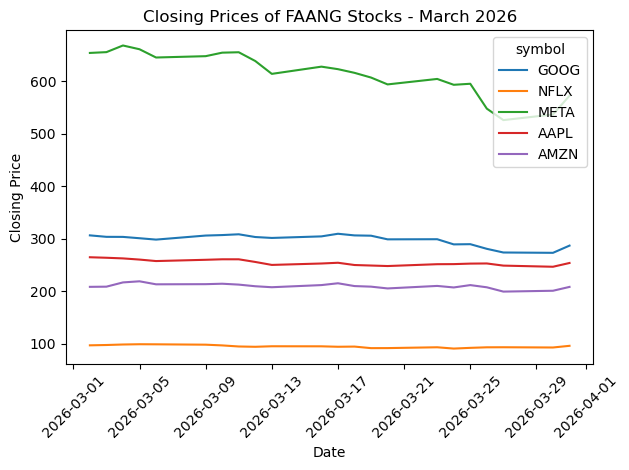

In [8]:
# Task 3a: Line chart of closing prices

import seaborn as sns
import matplotlib.pyplot as plt

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Sort values
df = df.sort_values("date")

# Plot
plt.figure()
sns.lineplot(data=df, x="date", y="close", hue="symbol")

plt.title("Closing Prices of FAANG Stocks - March 2026")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

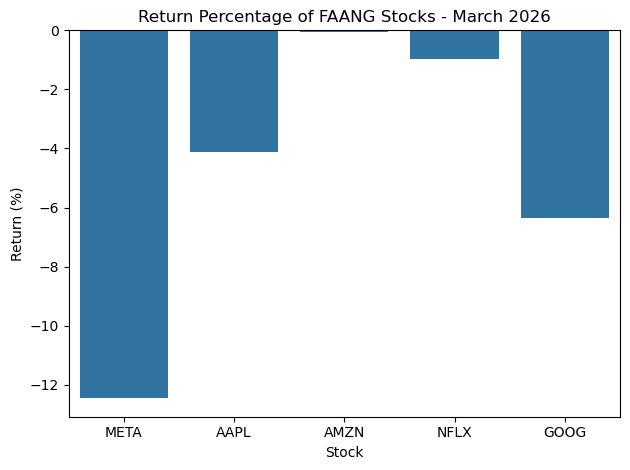

In [10]:
# Task 3b: Bar plot of returns

plt.figure()
sns.barplot(data=returns_df, x="Stock", y="Return (%)")

plt.title("Return Percentage of FAANG Stocks - March 2026")
plt.xlabel("Stock")
plt.ylabel("Return (%)")

plt.tight_layout()
plt.show()

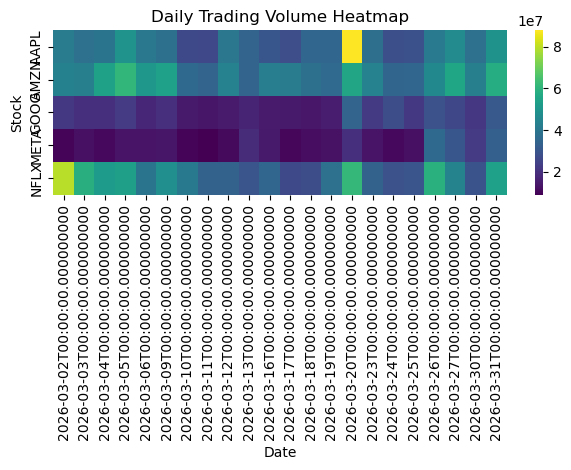

In [28]:
# Prepare data for heatmap

heatmap_data = df.pivot(index="symbol", columns="date", values="volume")

# Task 3c: Heatmap of trading volume

plt.figure()
sns.heatmap(heatmap_data, cmap="viridis")

plt.title("Daily Trading Volume Heatmap")
plt.xlabel("Date")
plt.ylabel("Stock")

plt.tight_layout()
plt.show()

# Task 3: Created visualizations including a line chart of closing prices,
# a bar plot of monthly returns, and a heatmap of daily trading volumes.

In [13]:
# Task 4a

import json
import os

# créer le dossier exports si il existe pas
os.makedirs("exports", exist_ok=True)

# exporter JSON brut
with open("exports/stockdata.json", "w") as f:
    json.dump(data, f)

print("JSON exported successfully")

JSON exported successfully


In [14]:
# Task 4b

df.to_csv("exports/stockdata.csv", index=False)

print("CSV exported successfully")

CSV exported successfully


In [15]:
# Task 4c

# reload JSON
with open("exports/stockdata.json", "r") as f:
    json_data = json.load(f)

# reload CSV
df_csv = pd.read_csv("exports/stockdata.csv")

print("JSON (first 5 rows):")
print(json_data["data"][:5])  # dépend de la structure API

print("\nCSV (first 5 rows):")
display(df_csv.head())

JSON (first 5 rows):
[{'open': 277.84, 'high': 287.05, 'low': 276.81, 'close': 286.86, 'volume': 30680107.0, 'adj_high': 287.05, 'adj_low': 276.76, 'adj_close': 286.86, 'adj_open': 277.54, 'adj_volume': 31625057.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'GOOG', 'exchange': 'XNAS', 'date': '2026-03-31T00:00:00+0000'}, {'open': 275.89, 'high': 276.26, 'low': 271.535, 'close': 273.14, 'volume': 21415696.0, 'adj_high': 276.26, 'adj_low': 271.535, 'adj_close': 273.14, 'adj_open': 275.44, 'adj_volume': 22752315.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'GOOG', 'exchange': 'XNAS', 'date': '2026-03-30T00:00:00+0000'}, {'open': 277.4, 'high': 279.09, 'low': 273.48, 'close': 273.76, 'volume': 25623591.0, 'adj_high': 279.09, 'adj_low': 273.48, 'adj_close': 273.76, 'adj_open': 277.4, 'adj_volume': 25703300.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'GOOG', 'exchange': 'XNAS', 'date': '2026-03-27T00:00:00+0000'}, {'open': 286.049, 'high': 286.515, 'low': 279.05, 'close': 2

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,302.93,308.14,301.06,306.36,21789144.0,308.14,301.06,306.36,302.965,21854368.0,1.0,0.0,GOOG,XNAS,2026-03-02 00:00:00+00:00
1,95.33,98.07,95.25,97.09,79614084.0,98.07,95.20,97.09,95.260,79915361.0,1.0,0.0,NFLX,XNAS,2026-03-02 00:00:00+00:00
2,637.16,659.94,634.50,653.56,9801700.0,659.94,634.50,653.56,637.160,9816125.0,1.0,0.0,META,ARCX,2026-03-02 00:00:00+00:00
3,262.44,266.53,260.20,264.72,41576035.0,266.53,260.20,264.72,262.410,41827946.0,1.0,0.0,AAPL,XNAS,2026-03-02 00:00:00+00:00
4,204.55,209.72,203.48,208.39,43410499.0,209.73,203.46,208.39,204.550,46001010.0,1.0,0.0,AMZN,XNAS,2026-03-02 00:00:00+00:00


In [29]:
print("\nVerification:")

print("Same number of rows:", len(df) == len(df_csv))
print("Same columns:", list(df.columns) == list(df_csv.columns))
print("The imported data appears identical to the original dataset.")

# Task 4: Exported the dataset to JSON and CSV files, then reloaded them
# to verify that the data remained consistent after saving and loading.


Verification:
Same number of rows: True
Same columns: True
The imported data appears identical to the original dataset.
